In [1]:
import numpy as np
import pickle

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, kendalltau

## Load data

In [2]:
train_data = np.load("data_processed/train_data.npz")
X_train = train_data["x"]

train_data_s = np.load("data_processed/train_data_scaled.npz")
X_train_s = train_data_s["x"]

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

## PCA explained variance

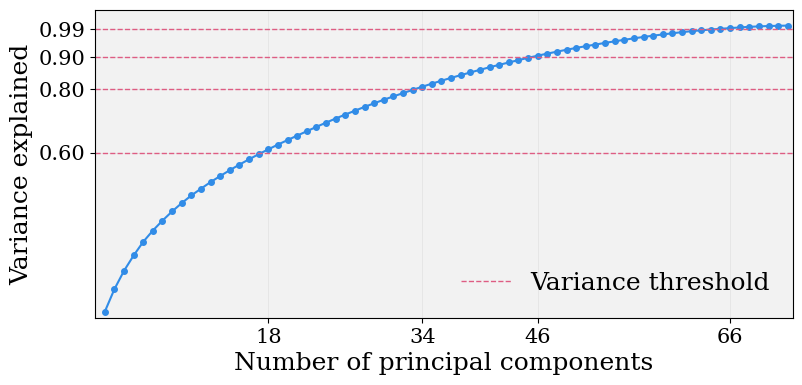

60% variance explained by 18 PCs
80% variance explained by 34 PCs
90% variance explained by 46 PCs
95% variance explained by 54 PCs
99% variance explained by 66 PCs


In [3]:
pca = PCA()
pca.fit(X_train_s)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.rcParams["font.family"] = "serif"

pca_color = "#318CE7"
threshold_color = "#DE5D83"

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o", markersize=4,
         color=pca_color,
        )
plt.axhline(0.60, linestyle="--", linewidth=1, color=threshold_color,
            label="Variance threshold")
plt.axhline(0.80, linestyle="--", linewidth=1, color=threshold_color)
plt.axhline(0.90, linestyle="--", linewidth=1, color=threshold_color)
plt.axhline(0.99, linestyle="--", linewidth=1, color=threshold_color)

ax = plt.gca()
ax.set_facecolor("#f2f2f2")

ax.set_xlim([0, 72.5])
ax.set_ylim([0.08, 1.05])
ax.grid(True, linewidth=0.4, alpha=0.3)
ax.set_xlabel("Number of principal components", fontsize=18)
ax.set_ylabel("Variance explained", fontsize=18)

plt.yticks([0.6, 0.8, 0.9, 0.99])
plt.xticks([18, 34, 46, 66])

ax.tick_params(axis='both', labelsize=15)

plt.legend(frameon=False, fontsize=18)

# plt.savefig("Results/PCA_train.pdf", bbox_inches="tight")

plt.show()

for threshold in [0.60, 0.80, 0.90, 0.95, 0.99]:
    k = np.searchsorted(cumulative, threshold) + 1
    print(f"{threshold:.0%} variance explained by {k} PCs")

## PCA feature importance

For each feature, we use the principal components $(\sigma_k,v_k)$ to compute

$\displaystyle r_j = \sum_{k=1}^d\sigma_k |v_{jk}|$

In [6]:
K = np.searchsorted(cumulative, 0.90) + 1

eigenvalues = pca.explained_variance_[:K]   
components = pca.components_[:K, :]         

loadings = pca.components_[:K, :]          
weights = explained[:K]                   

pca_scores = np.sum(weights[:, None] * np.abs(loadings), axis=0)

pca_importance = pd.DataFrame({
    "feature": feature_names,
    "PCA_score": pca_scores
}).sort_values("PCA_score", ascending=False)

pca_importance.head(10)

,feature,PCA_score
66,Triglycerides (mg/dl),0.092488
32,Glucose (mM),0.089846
70,Urea (mg/dl),0.089816
7,Acetone (mM),0.089623
35,Glutamine to glutamate ratio (unitless),0.089365
4,3-Hydroxyisobutyric acid (mM),0.089114
60,SPC (mM),0.089045
39,Glycine (mM),0.089012
64,Threonine (mM),0.088394
30,Ethanol (mM),0.088334


In [8]:
df = pd.DataFrame({'feature': feature_names, 
                   'score': pca_scores, 
                   'original_position': range(len(feature_names))
                  })

df_sorted = df.sort_values(by='score', ascending=False).reset_index(drop=True)
df_sorted['ranking'] = np.arange(1, len(feature_names)+1)

df.to_csv(f"Results/feature_rankings/pca_scores_unsorted.csv", index=False, float_format="%.6f")
df_sorted.to_csv(f"Results/feature_rankings/pca_scores.csv", index=False, float_format="%.6f")